FFNN's Parameters

In [1]:
h_neurons = 6
l_rate = 0.00379
epoch_size = 30
b_size = 8

Extracting the learning set and test set from the .txt file that generated during eucildean distance

In [2]:

def extract_L_set(filepath):
    l_set = []
    capture = False
    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
        
            # Start capturing when we see the header
            if line.startswith("L set:"):
                capture = True
                continue
        
            # Stop capturing when we reach the B vector
            if line.startswith("B vector:"):
                capture = False
                break
            
            # If we are in the capture zone and the line looks like a list
            if capture and line.startswith("["):
                # ast.literal_eval safely converts the string "[1, 2...]" into a Python list
                row = ast.literal_eval(line)
                l_set.append(row)
    return l_set

Including the text files from the results directiory of euclidean distance. from 2003 to 2023, training and validation.
And 2024 to 2025 for Test.

In [3]:
import numpy as np
import ast #abstract syntax tree module for safe evaluation of string.
import random
loaded_train_test_data = []
#first we loading the L set from 2003 to 2023
filePath = '../ED_Calculation/2003_2023/results/finalize_L_set_from_2003_to_2023.txt'
loaded_learning_data = np.array(extract_L_set(filePath))


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#separate the training_validation for Feature and Target
X = loaded_learning_data[:, :5] #first five col of the row is feature
y = loaded_learning_data[:, 5] # 6th value is the target

#split for train and val
X_train = X[30:]
X_val = X[:30]
y_train = y[30:]
y_val = y[:30]

scaler =  StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print(f"Shape of X_train {X_train.shape}")
print(f"Shape of y_train{y_train.shape}")
print(f"Shape of X_val{X_val.shape}")
print(f"Shape of y_val{y_val.shape}")

Shape of X_train (115, 5)
Shape of y_train(115,)
Shape of X_val(30, 5)
Shape of y_val(30,)


The test data from **2024 to 2025**.

In [5]:
loaded_test_data = []
test_filepath = "../ED_Calculation/2024_current/results/final_result_df_2024_2025.txt"
loaded_test_data = np.array(extract_L_set(test_filepath))
X_test = loaded_test_data[:, :5]
y_test = loaded_test_data[:, 5]

X_test = scaler.transform(X_test)


Now we are going to make a Feed Forward Neural Network, which has input layer with 5 feature, a hidden layer with non-linear function (sigmoid or relu), and a signle neuron output layer with linear function.
**The parameters are set at the top of this notebook**.

From seed 0 to 99, the ffnn trained, evaluate, and test. All the test prediction will do **median** at the last.

In [6]:
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
import pandas as pd


def direction_accuracy(y_true, y_pred):
    true_sign = tf.sign(y_true)
    pred_sign = tf.sign(y_pred)
    matches = tf.equal(true_sign, pred_sign)
    return tf.reduce_mean(tf.cast(matches, tf.float32)) * 100
# List to hold the predictions from all 100 runs
all_test_predictions = []
print(f"Start Training Model with Seed: 0 to 99")
# Loop through seeds 0 to 99
for current_seed in range(100):
    
    # Reset random seeds
    random.seed(current_seed)
    np.random.seed(current_seed)
    tf.random.set_seed(current_seed)
    
    # Build the model architecture 
    ffnn = Sequential()
    ffnn.add(Input(shape=(X_train.shape[1],)))
    ffnn.add(Dense(units=h_neurons, activation="relu")) 
    ffnn.add(Dense(units=1, activation="linear"))
    
    # Setup callbacks with unique filepaths per seed so they don't overwrite
    best_model_path = f'models/best_model_seed_{current_seed}.keras'
    
    early_stopping = EarlyStopping(
        monitor='val_direction_accuracy', mode='max', patience=5, restore_best_weights=True
    )
    checkpoint = ModelCheckpoint(
        filepath=best_model_path, monitor='val_direction_accuracy', 
        save_weights_only=False, mode='max', save_best_only=True, verbose=0
    )
    
    # Compile the model 
    ffnn.compile(
        optimizer=Adam(learning_rate=l_rate), 
        loss='mse', 
        metrics=[direction_accuracy]
    )
    
    # Fit the model 
    ffnn.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epoch_size, 
        batch_size=b_size,
        callbacks=[early_stopping, checkpoint],
        verbose=0 # Kept at 0 to avoid flooding console with 100 logs
    )
    
    # Load the best saved model for this specific seed
    best_model = tf.keras.models.load_model(
        best_model_path, custom_objects={'direction_accuracy': direction_accuracy}, compile=False
    )
    
    # Predict on the test set and flatten the array 
    y_pred = best_model.predict(X_test, verbose=0)
    all_test_predictions.append(np.ravel(y_pred))
    
    # Clear the Keras backend to prevent memory leaks during the loop
    tf.keras.backend.clear_session()
print(f"Completed Training Model with Seed: 0 to 99")

# --- Post-Processing: Median Calculation ---

# Convert the list to a NumPy matrix (Shape will be 100 rows x Number of Test Samples)
predictions_matrix = np.array(all_test_predictions)

# Calculate the median across the 0th axis (column-wise median per sample)
median_test_predictions = np.median(predictions_matrix, axis=0)

# Evaluate the ensemble (median) predictions against actual values [cite: 328, 329]
y_test_flat = np.ravel(y_test)
ffnn_direction_match = (np.sign(y_test_flat) == np.sign(median_test_predictions)).astype(int)

# Calculate and display the final ensemble accuracy
ffnn_test_acc = ffnn_direction_match.mean() * 100
print(f"\nFinal (Median) Test Prediction Accuracy: {ffnn_test_acc:.2f}%")

I0000 00:00:1779290181.482472 1253116 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779290182.172561 1253116 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779290184.158424 1253116 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Start Training Model with Seed: 0 to 99


E0000 00:00:1779290185.122947 1253116 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Completed Training Model with Seed: 0 to 99

Final (Median) Test Prediction Accuracy: 54.55%


--- Median Predictions vs Actual Values ---
      Actual  Median_Predicted  Direction_Match
0  -0.017473          0.053863                0
1  -0.339443          0.123258                0
2   0.031541          0.030838                1
3  -0.215161          0.082597                0
4  -0.087107          0.099853                0
5   0.485383          0.035376                1
6  -0.220254          0.077352                0
7   0.307394          0.037600                1
8   0.306878          0.041491                1
9   0.113420          0.096921                1
10  0.198257          0.098540                1


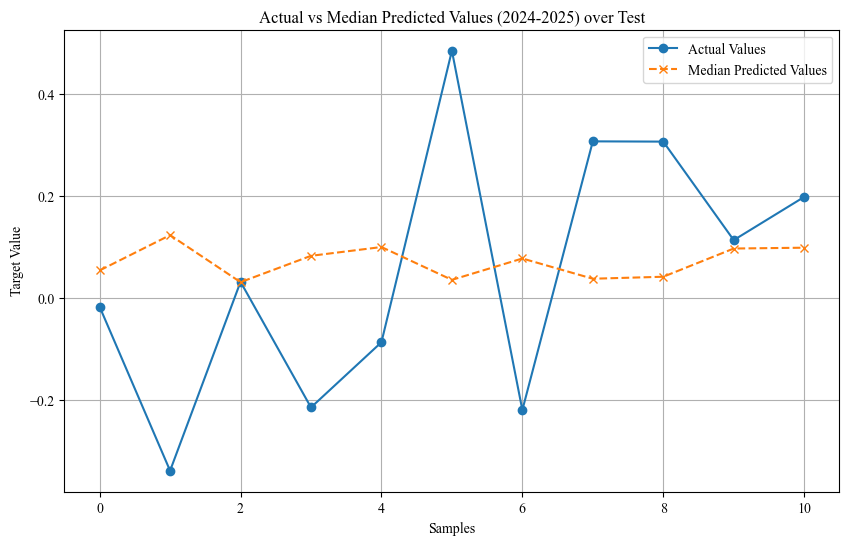

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame to view Actual vs Median Predicted values
median_results_df = pd.DataFrame({
    'Actual': y_test_flat,
    'Median_Predicted': median_test_predictions,
    'Direction_Match': ffnn_direction_match
})

print("--- Median Predictions vs Actual Values ---")
print(median_results_df)

# Plot the Actual vs Median Predicted values
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))

plt.plot(range(len(y_test_flat)), y_test_flat, label="Actual Values", marker="o")
plt.plot(range(len(median_test_predictions)), median_test_predictions, label="Median Predicted Values", marker="x", linestyle="--")

plt.title("Actual vs Median Predicted Values (2024-2025) over Test")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.savefig("relu_median.png", dpi=300, bbox_inches="tight")
plt.show()

Starting KNN here, then do ensembles consensus.

In [8]:
from sklearn.neighbors import KNeighborsRegressor
final_knn = KNeighborsRegressor(n_neighbors=2, metric='euclidean', weights='uniform')
final_knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Predictions of KNN

In [9]:
#final_knn.evaluate(X_test, y_test, verbose=1)
knn_pred = final_knn.predict(X_test)
knn_direction_match = (np.sign(y_test_flat) == np.sign(knn_pred)).astype(int)

import pandas as pd

knn_results = pd.DataFrame({
    'Actual': y_test_flat,
    'Predicted': knn_pred,
    'Direction': knn_direction_match
})
test_neg_match = ((knn_results['Actual'] < 0) & (knn_results['Predicted'] < 0)).sum()

# Count where actual > 0 AND predicted > 0  (positive match)
test_pos_match = ((knn_results['Actual'] > 0) & (knn_results['Predicted'] > 0)).sum()

print(knn_results)
final_knn_test_acc = knn_results['Direction'].mean() * 100
print(f"\nKNN Test Prediction Accuracy: {final_knn_test_acc:.2f}%")

      Actual  Predicted  Direction
0  -0.017473  -0.391660          1
1  -0.339443   0.291160          0
2   0.031541   0.043536          1
3  -0.215161   0.150028          0
4  -0.087107   0.352391          0
5   0.485383  -0.162532          0
6  -0.220254   0.861398          0
7   0.307394   0.446497          1
8   0.306878   0.066970          1
9   0.113420   0.790992          1
10  0.198257   0.104902          1

KNN Test Prediction Accuracy: 54.55%


**Ensemble Consensun Method**

In [10]:
# Flatten once at the start
med_flat = median_test_predictions.flatten()

# Ensemble
ensemble_preds = (knn_pred + med_flat) / 2
ensemble_acc = direction_accuracy(y_test_flat, ensemble_preds)

# Consensus loop
matches = 0
total_agreements = 0
for i in range(len(y_test_flat)):
    k_dir = 1 if knn_pred[i] >= 0 else -1
    f_dir = 1 if med_flat[i] >= 0 else -1
    actual = 1 if y_test_flat[i] >= 0 else -1

    agree = k_dir == f_dir
    match = agree and (k_dir == actual)

    if agree:
        total_agreements += 1
        if match:
            matches += 1

    print(f"{i:2d}. knn: {k_dir:2d} __ ffnn: {f_dir:2d} __ Actual: {actual:2d} __ Both Agree: {int(agree):2d} __ Match: {int(match):2d}")

consensus_acc = (matches / total_agreements * 100) if total_agreements > 0 else 0
print("===="*20)
print(f"KNN Test Prediction Accuracy: {final_knn_test_acc:.2f}%")
print(f"FFNN Test Prediction Accuracy(Median): {ffnn_test_acc:.2f}%")
print(f"Ensemble (Mean) Accuracy: {ensemble_acc:.2f}%")
print(f"Both Match: {matches}")
print(f"Consensus Accuracy (When they agree): {consensus_acc:.2f}%")
print(f"Confidence Rate: {(total_agreements/len(y_test))*100:.2f}% .. {total_agreements}/{len(y_test)} samples")

 0. knn: -1 __ ffnn:  1 __ Actual: -1 __ Both Agree:  0 __ Match:  0
 1. knn:  1 __ ffnn:  1 __ Actual: -1 __ Both Agree:  1 __ Match:  0
 2. knn:  1 __ ffnn:  1 __ Actual:  1 __ Both Agree:  1 __ Match:  1
 3. knn:  1 __ ffnn:  1 __ Actual: -1 __ Both Agree:  1 __ Match:  0
 4. knn:  1 __ ffnn:  1 __ Actual: -1 __ Both Agree:  1 __ Match:  0
 5. knn: -1 __ ffnn:  1 __ Actual:  1 __ Both Agree:  0 __ Match:  0
 6. knn:  1 __ ffnn:  1 __ Actual: -1 __ Both Agree:  1 __ Match:  0
 7. knn:  1 __ ffnn:  1 __ Actual:  1 __ Both Agree:  1 __ Match:  1
 8. knn:  1 __ ffnn:  1 __ Actual:  1 __ Both Agree:  1 __ Match:  1
 9. knn:  1 __ ffnn:  1 __ Actual:  1 __ Both Agree:  1 __ Match:  1
10. knn:  1 __ ffnn:  1 __ Actual:  1 __ Both Agree:  1 __ Match:  1
KNN Test Prediction Accuracy: 54.55%
FFNN Test Prediction Accuracy(Median): 54.55%
Ensemble (Mean) Accuracy: 54.55%
Both Match: 5
Consensus Accuracy (When they agree): 55.56%
Confidence Rate: 81.82% .. 9/11 samples


In [11]:
direction_knn = (np.sign(y_test_flat) == np.sign(knn_pred)).astype(int)
direction_ffnn = (np.sign(y_test_flat) == np.sign(med_flat)).astype(int)
direction_ffnn_knn = (np.sign(y_test_flat) == np.sign(ensemble_preds)).astype(int)
knn_ffnn_results = pd.DataFrame({
    'Actual': y_test_flat,
    'knn': knn_pred,
    'ffnn': med_flat,
    'knn+ffnn': ensemble_preds,
    'Direction': [f"K: {k} | F: {f} | FK: {fk}" for k, f, fk in zip(direction_knn, direction_ffnn, direction_ffnn_knn)]
})

print(knn_ffnn_results)

      Actual       knn      ffnn  knn+ffnn            Direction
0  -0.017473 -0.391660  0.053863 -0.168899  K: 1 | F: 0 | FK: 1
1  -0.339443  0.291160  0.123258  0.207209  K: 0 | F: 0 | FK: 0
2   0.031541  0.043536  0.030838  0.037187  K: 1 | F: 1 | FK: 1
3  -0.215161  0.150028  0.082597  0.116313  K: 0 | F: 0 | FK: 0
4  -0.087107  0.352391  0.099853  0.226122  K: 0 | F: 0 | FK: 0
5   0.485383 -0.162532  0.035376 -0.063578  K: 0 | F: 1 | FK: 0
6  -0.220254  0.861398  0.077352  0.469375  K: 0 | F: 0 | FK: 0
7   0.307394  0.446497  0.037600  0.242049  K: 1 | F: 1 | FK: 1
8   0.306878  0.066970  0.041491  0.054231  K: 1 | F: 1 | FK: 1
9   0.113420  0.790992  0.096921  0.443956  K: 1 | F: 1 | FK: 1
10  0.198257  0.104902  0.098540  0.101721  K: 1 | F: 1 | FK: 1


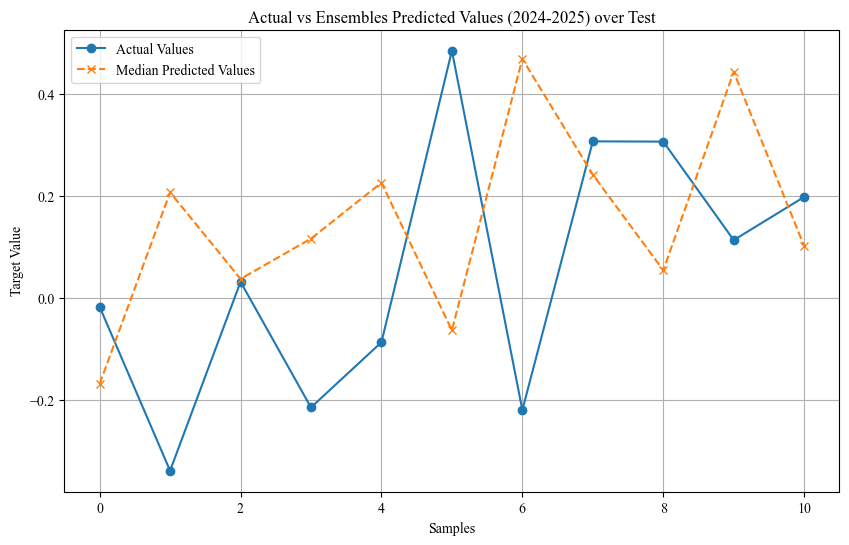

In [12]:
# Plot the Actual vs FFNN+KNN Predicted values
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))

plt.plot(range(len(y_test_flat)), y_test_flat, label="Actual Values", marker="o")
plt.plot(range(len(ensemble_preds)), ensemble_preds, label="Median Predicted Values", marker="x", linestyle="--")

plt.title("Actual vs Ensembles Predicted Values (2024-2025) over Test")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.savefig("knn_.png", dpi=300, bbox_inches="tight")
plt.show()

Three graphs Actual vs KNN vs FFNN vs Ensemble

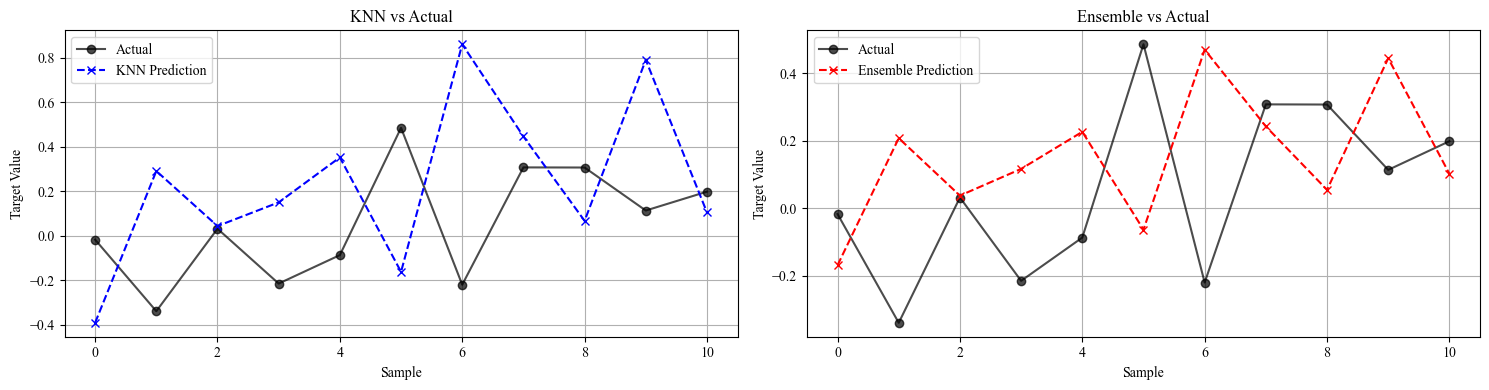

In [14]:
import matplotlib.pyplot as plt

# actual and predicted arrays
actual = y_test_flat
knn = knn_pred
ffnn = median_test_predictions.flatten()        # make sure it's 1D
ensemble = ensemble_preds

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# ----- Plot 1: KNN -----
axes[0].plot(range(len(actual)), actual, label="Actual", marker="o", color='black', alpha=0.7)
axes[0].plot(range(len(knn)), knn, label="KNN Prediction", marker="x", linestyle="--", color='blue')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Target Value')
axes[0].set_title('KNN vs Actual')
axes[0].legend()
axes[0].grid(True)

# ----- Plot 3: Ensemble -----
axes[1].plot(range(len(actual)), actual, label="Actual", marker="o", color='black', alpha=0.7)
axes[1].plot(range(len(ensemble)), ensemble, label="Ensemble Prediction", marker="x", linestyle="--", color='red')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Target Value')
axes[1].set_title('Ensemble vs Actual')
axes[1].legend()
axes[1].grid(True)



plt.tight_layout()
plt.savefig("relu_ffnn_knn_.png", dpi=300, bbox_inches="tight")
plt.show()